
# Machine Learning Portfolio Project

# Employee Attrition Prediction and Analysis Using Machine Learning

**Name:** Arya Tamhane

**Matrikelnummer:** 100006797

**Course:** Machine Learning 
    
**Dataset Used:** IBM HR Analytics Employee Attrition Dataset  



## Problem Statement

Employee attrition is a major challenge for organizations because it increases recruitment costs, reduces productivity, and affects long-term workforce stability. Accurately identifying employees who are likely to leave can help organizations take early preventive actions.

In this project, the IBM HR Analytics Employee Attrition dataset is used to analyze employee-related factors such as job role, experience, income, and satisfaction levels. Machine learning models are applied to:

- Predict whether an employee will leave the company (classification)
- Predict an employee’s monthly income (regression)

The goal of this analysis is not only to make predictions but to understand how different models perform, how employee features influence attrition and income, and how machine learning can support better workforce planning and decision-making.

### PART 1 - Problem Framing & ML Workflow

In this section, I prepare the dataset for machine learning.
                                      
#ML Workflow
                                      
I will:
- Understand the dataset
- Clean and preprocess the data
- Convert categorical values to numeric
- Split data into training and testing sets
- Scale the features

This prepares the data for modeling in later parts.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:

df = pd.read_csv("HR_Attrition.csv")

df.head()


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



***Data Cleaning & Preprocessing***

Steps performed:
- Handle missing values
- Encode categorical variables
- Feature scaling
- Train-test split


In [5]:

# Check missing values
df.isnull().sum()


Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

***Encoding Categorical Variables***

Machine learning models require numerical input.  
Categorical variables such as Department, JobRole, Gender etc. are converted into numeric values using Label Encoding.

In [6]:
le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,1,2,1102,2,1,2,1,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,0,1,279,1,8,1,1,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,1,2,1373,1,2,2,4,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,0,1,1392,1,3,4,1,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,0,2,591,1,2,1,3,1,7,...,4,80,1,6,3,3,2,2,2,2


***Feature and Target Selection***

Two prediction targets are defined:

- Classification Target → Attrition
- Regression Target → MonthlyIncome

All remaining columns are used as input features.

In [7]:
y_class = df['Attrition']        # Classification target
y_reg = df['MonthlyIncome']      # Regression target

X = df.drop(['Attrition', 'MonthlyIncome'], axis=1)

X.head()

,Age,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,2,1102,2,1,2,1,1,1,2,...,1,80,0,8,0,1,6,4,0,5
1,49,1,279,1,8,1,1,1,2,3,...,4,80,1,10,3,3,10,7,1,7
2,37,2,1373,1,2,2,4,1,4,4,...,2,80,0,7,3,3,0,0,0,0
3,33,1,1392,1,3,4,1,1,5,4,...,3,80,0,8,3,3,8,7,3,0
4,27,2,591,1,2,1,3,1,7,1,...,4,80,1,6,3,3,2,2,2,2


In [8]:
X_train, X_test, y_class_train, y_class_test = train_test_split(
    X, y_class, test_size=0.2, random_state=42)

_, _, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

***Feature Scaling***

I scale features so all columns have similar range.

This improves model performance, especially for distance-based models.

The output confirms scaling is complete.

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling complete.")

Feature scaling complete.


### PART 2 - Regression Analysis

Linear Regression is used to predict continuous values (Monthly Income).


***Feature Choice and Preprocessing***

Features used:
All columns except Attrition and MonthlyIncome.

Preprocessing already done in Part 1:

This ensures clean and consistent input for the regression model.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Train model
lr = LinearRegression()
lr.fit(X_train, y_reg_train)

LinearRegression()

In [20]:
y_pred_reg = lr.predict(X_test)

y_pred_reg[:10]   # first 10 predictions

array([ 6057.62548424,  5759.48822271,  2315.11400749, 11332.5457786 ,
        6504.96424376,  1898.47128201,  1913.41861821,  2372.50287455,
       10369.7075669 ,  1884.08659248])

In [21]:
mse = mean_squared_error(y_reg_test, y_pred_reg)
print("Mean Squared Error:", mse)

Mean Squared Error: 2266623.3977655815


***Mean Squared Error (MSE)***

MSE = 2266623.40

This value shows the average squared difference between actual and predicted Monthly Income.

Since income values range from about 1,000 to 20,000, this level of error is reasonable for salary prediction.

The model is making fairly accurate predictions, though some larger errors increase the squared value.

In [22]:
r2 = r2_score(y_reg_test, y_pred_reg)
print("R² Score:", r2)

R² Score: 0.8962900473656117


***R² Score***

R² = 0.8963

This means the model explains about 89.63% of the variation in Monthly Income.

Most of the salary differences between employees are captured by the selected features.

Only around 10% of variation is not explained by the model.

***Train vs Test Comparison***

To evaluate generalization and detect overfitting, train and test performance are compared.

In [23]:
# Train predictions
y_train_pred_reg = lr.predict(X_train)

print("Train R2:", r2_score(y_reg_train, y_train_pred_reg))
print("Test R2:", r2_score(y_reg_test, y_pred_reg))

print("Train MSE:", mean_squared_error(y_reg_train, y_train_pred_reg))
print("Test MSE:", mean_squared_error(y_reg_test, y_pred_reg))

Train R2: 0.9120805085155599
Test R2: 0.8962900473656117
Train MSE: 1947494.2545573898
Test MSE: 2266623.3977655815


***Train vs Test Comparison***

Train R² = 0.9121  
Test R² = 0.8963  

The difference between train and test performance is small (about 0.016).

This shows that the model generalizes well and is not strongly overfitting.

Train and test MSE values are also close, which supports model stability.

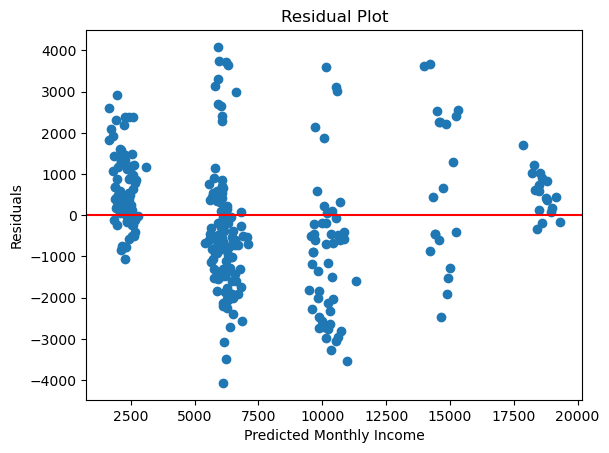

In [24]:
# Residuals for regression
residuals = y_reg_test - y_pred_reg

plt.scatter(y_pred_reg, residuals)
plt.axhline(0, color='red')
plt.xlabel("Predicted Monthly Income")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

***Residual Analysis***

The residual plot shows points scattered around zero without a clear pattern.

This means the linear relationship assumption is mostly valid.

There is some variation in spread across income ranges, but no strong curve pattern.

Overall, the model fits the data reasonably well.

***Model Performance***

The high R² and moderate MSE show that Linear Regression predicts Monthly Income well.

The model captures most of the relationship between employee features and salary.

***Overfitting vs Underfitting***

The model does not show strong overfitting because train and test scores are very similar.
Since Linear Regression assumes a straight-line relationship, there may be slight underfitting if some relationships are non-linear.
However, the high R² suggests that underfitting is not severe.

***Bias–Variance Perspective***

The model has moderate bias because it assumes a linear relationship.
The small gap between train and test results shows low variance.
Overall, the model achieves a good balance between bias and variance.

***Regression Conclusion***

The Linear Regression model performs well for predicting Monthly Income.

With R² = 0.8963 and a small train–test gap, the model explains most salary variation and generalizes well.

It provides a strong baseline regression model.

### Part 3 — Classification & Logistic Regression

In this section, I convert the problem into a classification task.

Target:
Attrition

0 → Employee stays  
1 → Employee leaves  

The goal is to predict whether an employee will leave the company.

***Train Logistic Regression Model***

Logistic Regression is used to predict employee attrition.
This model estimates the probability of leaving based on employee features.
By default, Logistic Regression uses L2 regularization, which helps prevent overfitting by controlling large coefficient values.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

log_model = LogisticRegression(max_iter=2000)
log_model.fit(X_train, y_class_train)

LogisticRegression(max_iter=2000)

In [28]:
y_pred_class = log_model.predict(X_test)

In [29]:
accuracy = accuracy_score(y_class_test, y_pred_class)
print("Accuracy:", accuracy)

Accuracy: 0.8945578231292517


Accuracy = 0.8946

The model correctly predicted about 89.46% of employees.

However, since most employees stay, high accuracy alone does not fully reflect performance.

In [30]:
cm = confusion_matrix(y_class_test, y_pred_class)
print(cm)

[[251   4]
 [ 27  12]]



- 251 employees correctly predicted as staying.
- 12 employees correctly predicted as leaving.
- 4 employees predicted as leaving but actually stayed.
- 27 employees predicted as staying but actually left.

The model performs very well for employees who stay but misses many who leave.

In [31]:
print(classification_report(y_class_test, y_pred_class))

              precision    recall  f1-score   support

           0       0.90      0.98      0.94       255
           1       0.75      0.31      0.44        39

    accuracy                           0.89       294
   macro avg       0.83      0.65      0.69       294
weighted avg       0.88      0.89      0.87       294



Precision (Attrition = 1) = 0.75  
Recall (Attrition = 1) = 0.31  

Precision means that when the model predicts "leave", it is correct 75% of the time.

Recall means the model only detects 31% of employees who actually leave.

This shows that many employees who leave are missed (false negatives).

For attrition prediction, recall is important because missing employees at risk of leaving can be costly.

***Model Behavior***

The model predicts "stay" very well but struggles to detect employees who leave.

High accuracy is mainly because most employees stay, so predicting "stay" is easier.

However, for attrition prediction, missing employees who leave can be important.

***Decision Threshold Impact***

The model uses the default decision threshold of 0.5.

Because recall is low (0.31), many leaving employees are not detected.

If the threshold is lowered:

- Recall would increase (catch more employees who leave)
- Precision may decrease

For employee retention, improving recall may be more important than maximizing accuracy.

***Coefficient Interpretation (Odds Ratio)***

To understand how features influence attrition, coefficients can be converted into odds ratios.

In [32]:

coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": log_model.coef_[0]
})

coeff_df["Odds_Ratio"] = np.exp(coeff_df["Coefficient"])

coeff_df.sort_values(by="Odds_Ratio", ascending=False).head()

,Feature,Coefficient,Odds_Ratio
20,OverTime,0.867724,2.381485
29,YearsAtCompany,0.689776,1.993269
18,NumCompaniesWorked,0.464692,1.591523
31,YearsSinceLastPromotion,0.458379,1.581508
16,MaritalStatus,0.449741,1.567906


***Key Feature Interpretation (Odds Ratio)***

- **OverTime (2.38)** → Employees working overtime are about 2.4 times more likely to leave. This is the strongest factor.
- **YearsAtCompany (1.99)** → Longer time at the company increases the chance of leaving.
- **NumCompaniesWorked (1.59)** → Employees who changed jobs more often are more likely to leave again.
- **YearsSinceLastPromotion (1.58)** → Longer gaps without promotion increase attrition risk.
- **MaritalStatus (1.57)** → Certain marital categories are associated with higher attrition.

Overall, overtime and career progression factors strongly influence employee attrition in this model.

### PART 4 - Model Comparison & Interpretability
In this section, I train two additional models:

- k-Nearest Neighbors (KNN)
- Decision Tree

I compare them using the same evaluation metric (Accuracy) to see which performs better.

In [34]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings("ignore")

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_class_train)

knn_pred = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_class_test, knn_pred))

KNN Accuracy: 0.8741496598639455


***KNN Model Accuracy***

The KNN model correctly predicted about 87.41% of employees.

It performs reasonably well but is slightly worse than Logistic Regression.

In [35]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_class_train)

dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_class_test, dt_pred))

Decision Tree Accuracy: 0.8231292517006803


***Decision Tree Accuracy***

The Decision Tree correctly predicted about 82.31% of employees.

This is lower than both Logistic Regression and KNN, showing weaker overall performance.

In [36]:

log_train_acc = accuracy_score(y_class_train, log_model.predict(X_train))
knn_train_acc = accuracy_score(y_class_train, knn.predict(X_train))
dt_train_acc = accuracy_score(y_class_train, dt.predict(X_train))

print("Logistic Regression Train Accuracy:", log_train_acc)
print("KNN Train Accuracy:", knn_train_acc)
print("Decision Tree Train Accuracy:", dt_train_acc)

Logistic Regression Train Accuracy: 0.8715986394557823
KNN Train Accuracy: 0.8732993197278912
Decision Tree Train Accuracy: 0.8988095238095238


In [37]:
from sklearn.model_selection import cross_val_score
import numpy as np

log_cv = cross_val_score(log_model, X_train, y_class_train, cv=5)
knn_cv = cross_val_score(knn, X_train, y_class_train, cv=5)
dt_cv = cross_val_score(dt, X_train, y_class_train, cv=5)

print("Logistic Regression CV Mean:", log_cv.mean())
print("Logistic Regression CV Std:", log_cv.std())

print("KNN CV Mean:", knn_cv.mean())
print("KNN CV Std:", knn_cv.std())

print("Decision Tree CV Mean:", dt_cv.mean())
print("Decision Tree CV Std:", dt_cv.std())

Logistic Regression CV Mean: 0.8520447169130906
Logistic Regression CV Std: 0.01050167826299852
KNN CV Mean: 0.840984493328525
KNN CV Std: 0.005817532583016675
Decision Tree CV Mean: 0.834186801298233
Decision Tree CV Std: 0.013413910585529404


In [38]:

comparison_table = pd.DataFrame({
    "Model": ["Logistic Regression", "KNN", "Decision Tree"],
    "Train Accuracy": [log_train_acc, knn_train_acc, dt_train_acc],
    "Test Accuracy": [0.8946, 0.8741, 0.8231],
    "CV Mean": [log_cv.mean(), knn_cv.mean(), dt_cv.mean()],
    "CV Std": [log_cv.std(), knn_cv.std(), dt_cv.std()]
})

comparison_table

,Model,Train Accuracy,Test Accuracy,CV Mean,CV Std
0,Logistic Regression,0.871599,0.8946,0.852045,0.010502
1,KNN,0.873299,0.8741,0.840984,0.005818
2,Decision Tree,0.898810,0.8231,0.834187,0.013414


***Bias–Variance Analysis***

Logistic Regression:
The train and test accuracy are close, and CV standard deviation is low (0.0105).
This indicates low variance and good generalization.

KNN:
Train and test accuracy are also close.
It has the lowest CV standard deviation (0.0058), meaning very stable performance.
However, overall accuracy is lower than Logistic Regression.

Decision Tree:
Train accuracy (0.8988) is much higher than test accuracy (0.8231).
This gap suggests higher variance and possible overfitting.
It also has the highest CV standard deviation (0.0134), confirming instability.

***Why Logistic Regression Performs Best***

Logistic Regression achieves the highest test accuracy (0.8946).

It maintains stable performance across folds (CV Mean = 0.8520, low std).

Unlike Decision Tree, it does not show a large train–test gap.

Compared to KNN, it captures the global linear relationship in the dataset more effectively.

Overall, Logistic Regression provides the best balance between accuracy, stability, and generalization.

***Interpretability and Transparency***

Logistic Regression:
Provides clear feature coefficients and odds ratios.
Easy to interpret and explain.

KNN:
Less interpretable because predictions depend on nearby data points.

Decision Tree:
Highly interpretable through decision rules,
but lower test accuracy reduces its practical reliability.

Logistic Regression offers the best combination of performance and interpretability.

### PART 5 - Advanced Model (Random Forest)

Random Forest combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_class_train)

rf_pred = rf.predict(X_test)

rf_accuracy = accuracy_score(y_class_test, rf_pred)
print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.8775510204081632



I use 5-fold cross validation to check how stable the model is across different data splits.

This helps measure how well the model generalizes to unseen data.

In [40]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(rf, X_train, y_class_train, cv=5)

print("Cross-validation scores:", cv_scores)
print("Average CV score:", cv_scores.mean())

Cross-validation scores: [0.85169492 0.85957447 0.84680851 0.85106383 0.84255319]
Average CV score: 0.8503389830508473


***Model Performance***

Random Forest Test Accuracy = 0.8776  
Average Cross-Validation Score = 0.8503  

The test accuracy is slightly higher than the cross-validation mean, but both are close.

This shows the model generalizes reasonably well.

***Cross Validation Interpretation***

Cross-validation scores:

[0.8517, 0.8596, 0.8468, 0.8511, 0.8426]

All scores are close to each other and around 0.85.

This shows the model is stable and does not change much with different training data.

***Bias–Variance Perspective***

Random Forest reduces variance compared to a single Decision Tree.

Since test accuracy (0.8776) and CV score (0.8503) are close, the model does not show strong overfitting.

The model has:
- Low variance (stable performance)
- Moderate bias (still not perfect prediction)

***Hyperparameter Impact***

The model uses 100 decision trees (n_estimators = 100).

Increasing the number of trees generally improves stability but increases computation time.

While Random Forest improves over a single Decision Tree, it does not outperform Logistic Regression in this dataset.

This suggests that increasing model complexity does not necessarily improve performance.

***Deployment Consideration***

Although Random Forest performs well (0.8776 accuracy) and shows stable cross-validation results, it does not achieve the highest test accuracy.

Logistic Regression performs better (0.8946) and is more interpretable.

Therefore, while Random Forest is stable and reduces variance, Logistic Regression remains preferable for deployment due to higher accuracy and better transparency.

***Overfitting Check***

There is no strong sign of overfitting because:

- Cross-validation score is close to test accuracy
- Model performance is stable across folds



### PART 6 — Unsupervised Learning (PCA)

In this section, I apply Principal Component Analysis (PCA).

PCA is an unsupervised method, which means it does not use the target variable.
The goal here is:
- To reduce the number of features
- To observe hidden structure in the dataset
- To understand how the data behaves without using labels

***Apply PCA***

Here I reduce the dataset into 2 principal components.

This means I am compressing many original features into just 2 new variables
that capture most of the important information in the data.

In [41]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

print("Explained variance ratio:", pca.explained_variance_ratio_)

Explained variance ratio: [0.98972901 0.0070939 ]


***Quantitative PCA Interpretation***

Explained Variance Ratio:
- Principal Component 1 = 98.97%
- Principal Component 2 = 0.71%

This means almost all variation in the dataset is captured by the first component.

The second component adds very little additional information.

Therefore, the dataset effectively varies along one dominant direction.

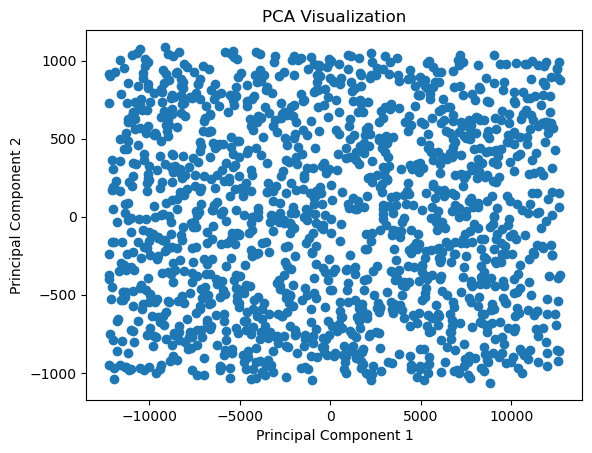

In [42]:
import matplotlib.pyplot as plt

plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")
plt.show()

***Discovered Structure***

Since 98.97% of variance is explained by PC1, the features are highly correlated.

The PCA scatter plot does not show clear separate clusters.

This indicates the dataset does not naturally divide into distinct groups.

Instead, most employee characteristics move together along a single main trend.

***Quantitative Insight***

The difference between PC1 (98.97%) and PC2 (0.71%) is very large.

This confirms that dimensionality can be reduced significantly without losing much information.

It also suggests strong multicollinearity among features.

***Connection to Supervised Learning Results***

Since most variance is captured in one main direction, the dataset likely follows a strong linear structure.

This explains why Logistic Regression performed best (Test Accuracy = 0.8946).

Linear models benefit when the data structure is dominated by one primary component.

The lack of clear clusters also explains why more complex models (Decision Tree, Random Forest) did not significantly outperform Logistic Regression.

***Usefulness of Unsupervised Learning***

From PCA, I understood that almost all the variation (98.97%) is captured in just one main component.

This means many features are moving together and are strongly related to each other.

It also shows that the dataset mainly follows one dominant direction instead of forming clear separate groups.

Because of this strong linear structure, simpler models like Logistic Regression performed better in my supervised analysis.

So even though PCA does not use the target variable, it helped me understand why the classification results behaved the way they did.


### PART 7 — Neural Network

Neural networks capture nonlinear patterns.


In [43]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# Train simple neural network
nn = MLPClassifier(hidden_layer_sizes=(50,), max_iter=500, random_state=42)
nn.fit(X_train, y_class_train)

# Predictions
nn_pred = nn.predict(X_test)

# Accuracy
nn_accuracy = accuracy_score(y_class_test, nn_pred)
print("Neural Network Accuracy:", nn_accuracy)

print(classification_report(y_class_test, nn_pred))

Neural Network Accuracy: 0.826530612244898
              precision    recall  f1-score   support

           0       0.90      0.91      0.90       255
           1       0.33      0.31      0.32        39

    accuracy                           0.83       294
   macro avg       0.61      0.61      0.61       294
weighted avg       0.82      0.83      0.82       294



In [44]:
# Train Accuracy
nn_train_pred = nn.predict(X_train)
nn_train_acc = accuracy_score(y_class_train, nn_train_pred)

print("Neural Network Train Accuracy:", nn_train_acc)
print("Neural Network Test Accuracy:", nn_accuracy)

Neural Network Train Accuracy: 1.0
Neural Network Test Accuracy: 0.826530612244898


***Neural Network Architecture***

I trained a Multi-Layer Perceptron (MLP) with:

- 1 hidden layer
- 50 neurons
- ReLU activation (default in sklearn)
- Maximum 500 iterations (epochs)

This is a simple feedforward neural network designed to capture nonlinear relationships.

**Train vs Test Performance**

Train Accuracy = 1.00  
Test Accuracy = 0.8265  

The model perfectly fits the training data but performs much lower on test data.

This shows clear overfitting.

The network memorized the training data instead of learning patterns that generalize well.

**Comparing its behavior to classical models**

When I compare the neural network to the classical models, I notice clear differences.

**Performance:**  
The neural network achieved 82.65% test accuracy, which is lower than Logistic Regression (89.46%), Random Forest (87.76%), and KNN (87.41%).  
It also had 100% training accuracy, which shows strong overfitting.  
It performs well in predicting employees who stay, but struggles to correctly identify employees who leave (recall = 0.31).

**Interpretability:**  
Unlike Logistic Regression, the neural network does not provide clear feature importance or coefficients.  
I cannot easily explain how each feature affects the prediction.  
This makes it less transparent compared to Logistic Regression or Decision Tree.

**Practical Limitations:**  
The model overfits the training data.  
It requires more tuning (layers, neurons, epochs).  
It is computationally heavier and harder to explain.  
Since it does not improve performance, the added complexity is not justified for this dataset.

Overall, based on my results, simpler classical models perform better and are easier to interpret.

### PART 8 - Ethics & Explainability

In this project, I trained multiple models to predict employee attrition. 
Before using such models in real life, I believe it is important to consider fairness, bias, and transparency.

***Fairness and Bias:***

From earlier results, most models predicted employees who stay very well, but struggled to correctly identify employees who leave (low recall for attrition class). This shows a bias toward the majority class (employees who stay). If used in real life, this could lead to missing employees who are at risk of leaving, which may result in unfair or incomplete decisions.

Another possible source of bias comes from dataset features such as job role, income, experience, and overtime. If these features reflect historical or organizational bias, the model may unintentionally learn and repeat those patterns.

***Transparency and Explainability:***

Logistic Regression and Decision Tree are easier to explain.
Since Logistic Regression provides clear coefficients and odds ratios, I can understand how features like OverTime influence attrition.
Random Forest and Neural Network are harder to interpret, which reduces transparency.
For sensitive HR decisions, I believe interpretability is very important.

***Responsible ML Deployment:***

Machine learning predictions should not be used as the only decision factor. Before deployment:
- The model should be checked for bias and fairness.
- Predictions should support, not replace, human judgment.
- The model should be monitored and updated regularly.
- Sensitive decisions should remain explainable and accountable.

***Mitigation Strategy:***

To reduce this fairness issue, I would:

- Adjust the decision threshold to improve recall for the attrition class.
- Use class balancing techniques (like class_weight or resampling).
- Monitor model performance separately for different employee groups.

This would help reduce bias toward the majority class and improve fairness.



### FINAL REFLECTION

## 1) Model to Deploy:

Based on my results, I would deploy Logistic Regression.
It achieved the highest test accuracy (0.8946), showed stable cross-validation performance (~0.852), and did not show strong overfitting.
In contrast, the Neural Network overfitted (train accuracy = 1.00, test = 0.8265).
Logistic Regression also provides clear interpretability through feature coefficients.
Because of its accuracy, stability, and transparency, I believe it is the most suitable model.
    
## 2) Most Important Evaluation Metric:

The most important metric in this project was **Recall for the attrition class (employees who leave)**.  
Since detecting employees who may leave is more critical than predicting those who stay, recall matters more than overall accuracy.
Most models had recall around 0.31 for attrition, which shows this is still a challenge.

## 3) Trade-offs Encountered:

I observed a trade-off between complexity and generalization.
More complex models like Neural Network and Random Forest did not outperform Logistic Regression.
The neural network even overfitted the training data.
This showed me that increasing complexity does not always improve performance.
    
## 4) Limitations:

The dataset is relatively small.
There is class imbalance, which affects recall for attrition cases.
Also, I performed limited hyperparameter tuning.
The neural network clearly showed overfitting, which indicates more tuning is required.

## 5) Improvements with More Time or Data:

With more time, I would:

- Perform deeper hyperparameter tuning.
- Apply class balancing techniques.
- Explore threshold adjustment to improve recall.
- Test fairness across different employee groups.
- Use more diverse data to improve generalization.

This would improve both model performance and reliability for real-world deployment.